# Sillage (Backtest)

**Role framing:** supply chain planner. Forecast demand early from social signals → estimate supply needed before stockout.

**Two cases:**
- **Bianco Latte** - new release. No sales history at launch → social signal is the *only* early read.
- **Stronger With You Intensely (SWYI)** - established seasonal. Fragrantica season prior + social confirm/size the surge.

**Signals:** Google Trends (demand proxy / target) · Reddit sentiment (leads) + mentions (nowcast) · TikTok posting velocity · Fragrantica accords→season (static product prior).

*No ratings used (leakage). Google is a demand proxy - same pipeline holds with real POS data.*

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"

# Fragrantica static product attributes (accords + derived season)
frag = pd.read_csv(PROCESSED / "fragrantica.csv")

def load_sku(slug, sku_name):
    df = pd.read_csv(PROCESSED / f"{slug}_combined.csv", parse_dates=["week"])
    df = df.sort_values("week").reset_index(drop=True)
    df["google_interest"] = df["google_interest"].ffill().fillna(0)
    # attach static fragrantica season for this SKU (if present)
    row = frag[frag["sku"] == sku_name]
    df["season"] = row["season"].iloc[0] if len(row) else "unknown"
    df["accords"] = row["accords"].iloc[0] if len(row) else ""
    return df

SKUS = {
    "bianco_latte": "Bianco Latte",
    "stronger_with_you_intensely": "Stronger With You Intensely",
}

# quick check
for slug, name in SKUS.items():
    d = load_sku(slug, name)
    print(f'{name:<32} {d.shape[0]} wks | season={d["season"].iloc[0]:<13} | '
          f'google max={d.google_interest.max():.0f} reddit total={d.reddit_mentions.sum()}')

Bianco Latte                     157 wks | season=cold-weather  | google max=100 reddit total=3086
Stronger With You Intensely      157 wks | season=cold-weather  | google max=100 reddit total=2488


In [3]:
def make_features(df, lags=(1, 2, 3, 4)):
    """Build leakage-safe modeling table.
    Target = google_interest (this week's demand).
    Features = PAST social signals (lagged) + calendar + static season prior.
    """
    out = df[["week", "google_interest"]].copy()

    # --- lagged social features (past buzz -> predict current demand) ---
    for col in ["reddit_mentions", "reddit_pos_mentions", "reddit_net_sentiment"]:
        for k in lags:
            out[f"{col}_lag{k}"] = df[col].shift(k)

    # --- autoregressive: demand also depends on its own recent past ---
    for k in lags:
        out[f"google_lag{k}"] = df["google_interest"].shift(k)

    # --- calendar (lets the model learn seasonality) ---
    out["month"] = df["week"].dt.month
    out["week_of_year"] = df["week"].dt.isocalendar().week.astype(int)

    # --- static product prior from Fragrantica ---
    out["is_cold_weather"] = int(df["season"].iloc[0] == "cold-weather")

    # drop rows with NaN lags (first few weeks)
    out = out.iloc[max(lags):].reset_index(drop=True)
    return out

# build for both
feats = {slug: make_features(load_sku(slug, name)) for slug, name in SKUS.items()}

for slug, f in feats.items():
    print(f"{slug:<32} {f.shape[0]} rows × {f.shape[1]} cols")

feats["bianco_latte"].head(5)


bianco_latte                     153 rows × 21 cols
stronger_with_you_intensely      153 rows × 21 cols


,week,google_interest,reddit_mentions_lag1,reddit_mentions_lag2,reddit_mentions_lag3,reddit_mentions_lag4,reddit_pos_mentions_lag1,reddit_pos_mentions_lag2,reddit_pos_mentions_lag3,reddit_pos_mentions_lag4,...,reddit_net_sentiment_lag2,reddit_net_sentiment_lag3,reddit_net_sentiment_lag4,google_lag1,google_lag2,google_lag3,google_lag4,month,week_of_year,is_cold_weather
0,2023-01-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,2.0,2.0,0.0,1,5,1
1,2023-02-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,2.0,2.0,2,6,1
2,2023-02-13,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,2.0,2,7,1
3,2023-02-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,3.0,2,8,1
4,2023-02-27,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2,9,1


In [4]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

def split_at(feats_df, cutoff_week):
    """Train on weeks <= cutoff, test on weeks after. Time-ordered, no shuffle."""
    cutoff = pd.Timestamp(cutoff_week)
    train = feats_df[feats_df.week <= cutoff]
    test  = feats_df[feats_df.week >  cutoff]
    feature_cols = [c for c in feats_df.columns if c not in ("week", "google_interest")]
    Xtr, ytr = train[feature_cols], train["google_interest"]
    Xte, yte = test[feature_cols],  test["google_interest"]
    return Xtr, ytr, Xte, yte, test["week"], feature_cols

# SWYI first — established seasonal product.
# Cut just BEFORE the 2024 winter spike: train on everything up to Oct 2024.
slug = "stronger_with_you_intensely"
cutoff = "2024-10-31"
Xtr, ytr, Xte, yte, test_weeks, fcols = split_at(feats[slug], cutoff)

print(f"SWYI  cutoff={cutoff}")
print(f"  train: {len(Xtr)} weeks (through {cutoff})")
print(f"  test:  {len(Xte)} weeks (the held-out future we predict)")
print(f"  features: {len(fcols)}")


SWYI  cutoff=2024-10-31
  train: 92 weeks (through 2024-10-31)
  test:  61 weeks (the held-out future we predict)
  features: 19


In [13]:
# Pool ALL Reddit SKUs into one table so the model learns category seasonality
ALL_SKUS = {
    "phlur_vanilla_skin": "Phlur Vanilla Skin",
    "bianco_latte": "Bianco Latte",
    "ysl_myslf": "YSL MYSLF",
    "louis_vuitton_imagination": "Louis Vuitton Imagination",
    "stronger_with_you_intensely": "Stronger With You Intensely",
    "glossier_you": "Glossier You",
    "dior_sauvage": "Dior Sauvage",
    "miss_dior_parfum": "Miss Dior Parfum",
    "ysl_libre": "YSL Libre",
    "secretions_magnifiques": "Secretions Magnifiques",
}

pooled = []
for slug, name in ALL_SKUS.items():
    f = make_features(load_sku(slug, name))
    f["sku"] = slug
    pooled.append(f)
pooled = pd.concat(pooled, ignore_index=True)

print(f"pooled: {pooled.shape[0]} rows ({len(ALL_SKUS)} SKUs × ~153 wks), {pooled.shape[1]} cols")
print("SKUs:", pooled.sku.nunique())
pooled.groupby("sku").size()

pooled: 1530 rows (10 SKUs × ~153 wks), 22 cols
SKUs: 10


sku
bianco_latte                   153
dior_sauvage                   153
glossier_you                   153
louis_vuitton_imagination      153
miss_dior_parfum               153
phlur_vanilla_skin             153
secretions_magnifiques         153
stronger_with_you_intensely    153
ysl_libre                      153
ysl_myslf                      153
dtype: int64

## Bianco Latte Giardini Di Toscana
<img src="images/biancolatte.webp" width="250">

In [12]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# Features: social + calendar + season. Add per SKU demand history is fine here
# because the model is learning ACROSS skus (seasonality), not memorizing one.
feature_cols = [c for c in pooled.columns if c not in ("week", "google_interest", "sku")]

# Hold out Bianco's launch window as the test; train on everything else.
launch_start = pd.Timestamp("2023-09-01")
launch_end   = pd.Timestamp("2024-02-01")
is_bianco_launch = (pooled.sku == "bianco_latte") & \
                   (pooled.week >= launch_start) & (pooled.week <= launch_end)

train = pooled[~is_bianco_launch]
test  = pooled[is_bianco_launch]

model = GradientBoostingRegressor(n_estimators=300, max_depth=3,
                                  learning_rate=0.05, random_state=42)
model.fit(train[feature_cols], train["google_interest"])

test = test.copy()
test["pred"] = model.predict(test[feature_cols])
print(f"Bianco launch,  actual vs forecast (model never saw this window):")
print(test[["week","google_interest","pred"]].to_string(index=False))
print(f"\nMAE: {mean_absolute_error(test.google_interest, test.pred):.1f}")


Bianco launch,  actual vs forecast (model never saw this window):
      week  google_interest      pred
2023-09-04             15.0  8.877096
2023-09-11             17.0 12.233599
2023-09-18             16.0 15.314276
2023-09-25             13.0 16.489702
2023-10-02             16.0 13.859647
2023-10-09             13.0 16.518609
2023-10-16            100.0 14.409026
2023-10-23             63.0 36.509021
2023-10-30             57.0 59.744550
2023-11-06             39.0 61.473427
2023-11-13             45.0 51.162596
2023-11-20             46.0 58.036185
2023-11-27             96.0 48.560975
2023-12-04             71.0 72.032800
2023-12-11             70.0 66.125267
2023-12-18             70.0 72.672315
2023-12-25             54.0 67.400253
2024-01-01             41.0 51.285831
2024-01-08             37.0 37.514300
2024-01-15             27.0 39.493462
2024-01-22             28.0 28.215872
2024-01-29             26.0 28.229082

MAE: 12.3


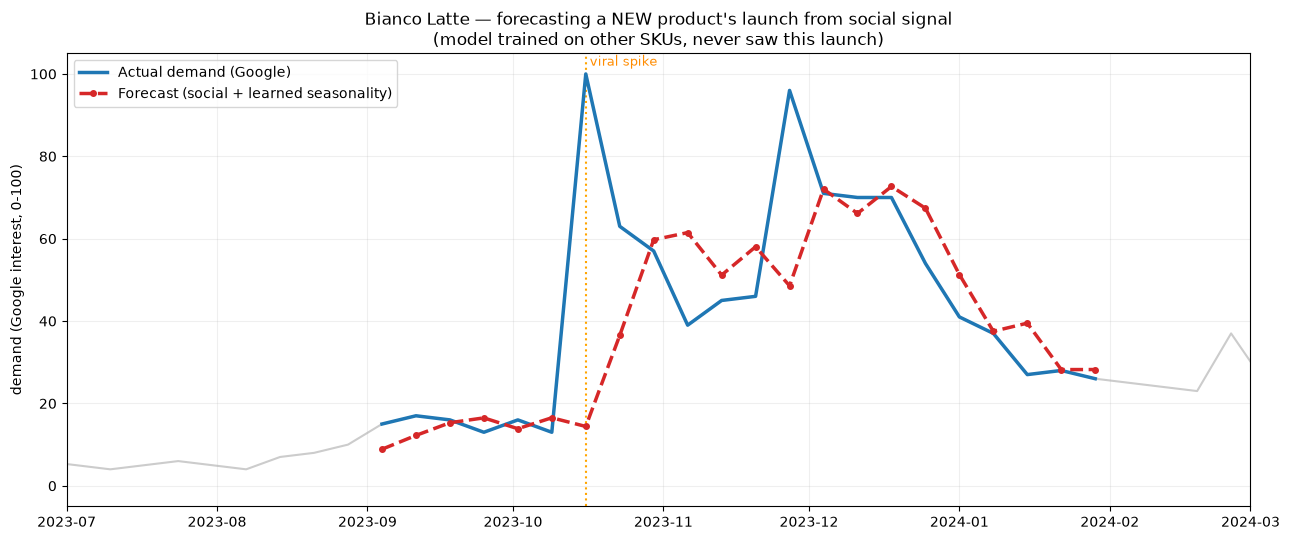

In [8]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# full actual demand line for context (faded outside the test window)
fb = pooled[pooled.sku == "bianco_latte"]
ax.plot(fb.week, fb.google_interest, color="#cccccc", lw=1.5, label="_nolegend_", zorder=1)

# actual demand in the launch window (bold)
ax.plot(test.week, test.google_interest, color="#1f77b4", lw=2.5,
        label="Actual demand (Google)", zorder=3)

# forecast (the model never saw this window)
ax.plot(test.week, test.pred, color="#d62728", lw=2.5, ls="--",
        marker="o", ms=4, label="Forecast (social + learned seasonality)", zorder=4)

# mark the viral explosion
ax.axvline(pd.Timestamp("2023-10-16"), color="orange", ls=":", lw=1.5)
ax.text(pd.Timestamp("2023-10-16"), 102, " viral spike", color="darkorange", fontsize=9)

ax.set_title("Bianco Latte — forecasting a NEW product's launch from social signal\n"
             "(model trained on other SKUs, never saw this launch)", fontsize=12)
ax.set_ylabel("demand (Google interest, 0-100)")
ax.set_xlim(pd.Timestamp("2023-07-01"), pd.Timestamp("2024-03-01"))
ax.legend(loc="upper left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(ROOT / "data" / "charts" / "bianco_launch_forecast.png", dpi=120)
plt.show()


## Stronger With You Intensely
<img src="images/swyi.png" width="250">

In [9]:
# SWYI — established seasonal. Hold out the Nov 2024 - early 2025 winter spike.
swyi_test_start = pd.Timestamp("2024-11-01")
swyi_test_end   = pd.Timestamp("2025-02-01")
is_swyi_test = (pooled.sku == "stronger_with_you_intensely") & \
               (pooled.week >= swyi_test_start) & (pooled.week <= swyi_test_end)

train_s = pooled[~is_swyi_test]
test_s  = pooled[is_swyi_test].copy()

model_s = GradientBoostingRegressor(n_estimators=300, max_depth=3,
                                    learning_rate=0.05, random_state=42)
model_s.fit(train_s[feature_cols], train_s["google_interest"])
test_s["pred"] = model_s.predict(test_s[feature_cols])

print("SWYI winter spike — actual vs forecast (model never saw this window):")
print(test_s[["week","google_interest","pred"]].to_string(index=False))
print(f"\nMAE: {mean_absolute_error(test_s.google_interest, test_s.pred):.1f}")


SWYI winter spike — actual vs forecast (model never saw this window):
      week  google_interest      pred
2024-11-04             52.0 42.142908
2024-11-11             56.0 55.517037
2024-11-18            100.0 63.107586
2024-11-25             82.0 71.057409
2024-12-02             70.0 74.813738
2024-12-09             83.0 77.608833
2024-12-16            100.0 92.059510
2024-12-23             52.0 73.068025
2024-12-30             41.0 45.131278
2025-01-06             35.0 42.202153
2025-01-13             29.0 33.849986
2025-01-20             26.0 29.994153
2025-01-27             27.0 25.378667

MAE: 9.2


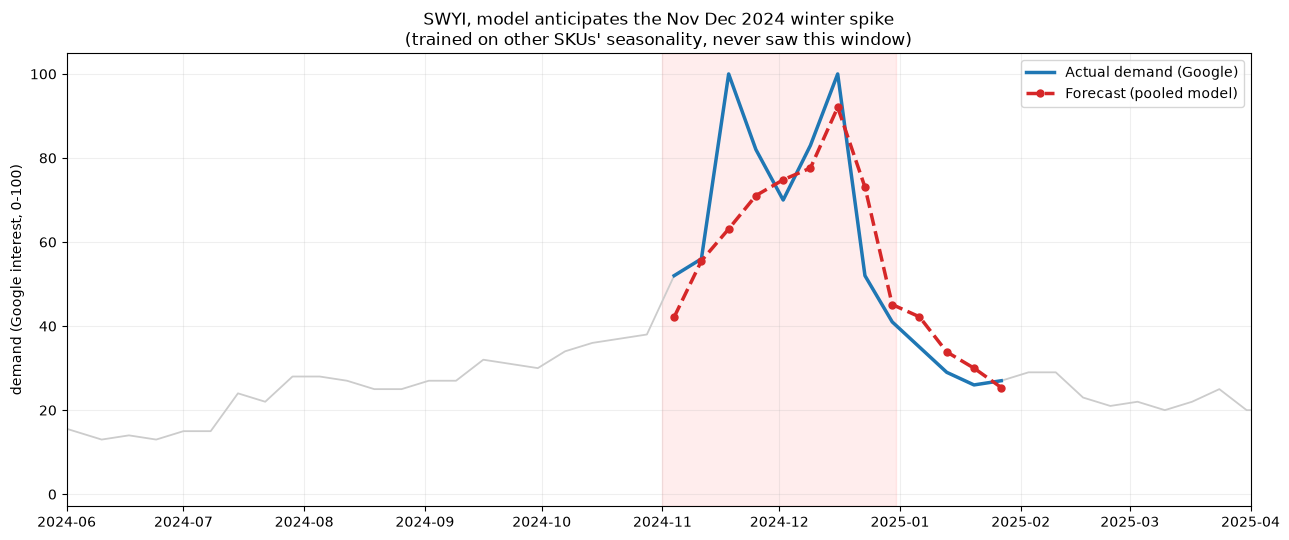

In [11]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# full demand history for context (faded)
fs = pooled[pooled.sku == "stronger_with_you_intensely"]
ax.plot(fs.week, fs.google_interest, color="#cccccc", lw=1.3)

# actual demand in the test window (bold)
ax.plot(test_s.week, test_s.google_interest, color="#1f77b4", lw=2.5,
        label="Actual demand (Google)")

# forecast (model never saw this window)
ax.plot(test_s.week, test_s.pred, color="#d62728", lw=2.5, ls="--",
        marker="o", ms=5, label="Forecast (pooled model)")

ax.axvspan(pd.Timestamp("2024-11-01"), pd.Timestamp("2024-12-31"),
           color="red", alpha=0.07)
ax.set_title("SWYI, model anticipates the Nov Dec 2024 winter spike\n"
             "(trained on other SKUs' seasonality, never saw this window)", fontsize=12)
ax.set_ylabel("demand (Google interest, 0-100)")
ax.set_xlim(pd.Timestamp("2024-06-01"), pd.Timestamp("2025-04-01"))
ax.legend(loc="upper right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(ROOT / "data" / "charts" / "swyi_forecast.png", dpi=120)
plt.show()

In [18]:
# --- Translate forecast into supply planning numbers (proxy-scaled; swap for real POS) ---
UNITS_PER_INTEREST = 10      # Google interest 100 -> 1000 units/week
LEAD_TIME_WK = 4             # order-to-shelf lead time
Z = 1.65                     # ~95% service level

def supply_plan(test_df, full_df, label):
    """Translate demand forecast into supply planning numbers."""
    d = test_df.sort_values("week").copy()
    d["actual_units"]   = d["google_interest"] * UNITS_PER_INTEREST
    d["forecast_units"] = d["pred"].clip(lower=0) * UNITS_PER_INTEREST

    # baseline demand (pre-spike) sets nominal stock & safety stock
    pre = full_df[full_df.week < d.week.min()]["google_interest"].tail(8) * UNITS_PER_INTEREST
    base_demand = pre.mean()
    sigma = pre.std()
    safety_stock = Z * sigma * np.sqrt(LEAD_TIME_WK)
    reorder_point = base_demand * LEAD_TIME_WK + safety_stock

    return d, dict(base_demand=base_demand, safety_stock=safety_stock,
                   reorder_point=reorder_point, label=label)

plan_s, info_s = supply_plan(test_s, fs, "SWYI")
plan_b, info_b = supply_plan(test, fb, "Bianco Latte")

for info in (info_s, info_b):
    print(f"{info['label']:<14} base demand ~{info['base_demand']:.0f} u/wk | "
          f"safety stock {info['safety_stock']:.0f} | reorder point {info['reorder_point']:.0f}")

SWYI           base demand ~331 u/wk | safety stock 125 | reorder point 1450
Bianco Latte   base demand ~61 u/wk | safety stock 69 | reorder point 314


## The 2025 Reformulation (Reimagined by Francis Kurkdjian) 
<img src="images/diorhomme.jpg" width="200">

In [20]:
# Add Dior Homme Parfum,  the REFORMULATION case (Q1 2025 demand surge)
dhp = make_features(load_sku("dior_homme_parfum", "Dior Homme Parfum"))
dhp["sku"] = "dior_homme_parfum"
pooled_dhp = pd.concat([pooled, dhp], ignore_index=True)

# Hold out DHP's Q1-Q2 2025 (reformulation window). Train on everything else.
dhp_test_start = pd.Timestamp("2025-01-01")
dhp_test_end   = pd.Timestamp("2025-06-30")
is_dhp_test = (pooled_dhp.sku == "dior_homme_parfum") & \
              (pooled_dhp.week >= dhp_test_start) & (pooled_dhp.week <= dhp_test_end)

train_d = pooled_dhp[~is_dhp_test]
test_d  = pooled_dhp[is_dhp_test].copy()

model_d = GradientBoostingRegressor(n_estimators=300, max_depth=3,
                                    learning_rate=0.05, random_state=42)
model_d.fit(train_d[feature_cols], train_d["google_interest"])
test_d["pred"] = model_d.predict(test_d[feature_cols])

print("Dior Homme Parfum - Q1-Q2 2025 forecast (reformulation window, held out):")
print(test_d[["week","google_interest","pred"]].to_string(index=False))
print(f"\nMAE: {mean_absolute_error(test_d.google_interest, test_d.pred):.1f}")

Dior Homme Parfum - Q1-Q2 2025 forecast (reformulation window, held out):
      week  google_interest      pred
2025-01-06             66.0 63.528298
2025-01-13             73.0 58.390302
2025-01-20             63.0 67.053151
2025-01-27             50.0 53.831543
2025-02-03             53.0 42.750156
2025-02-10             43.0 47.143249
2025-02-17             44.0 41.826295
2025-02-24             38.0 40.930425
2025-03-03             37.0 37.310667
2025-03-10             34.0 34.354918
2025-03-17             34.0 34.756098
2025-03-24             31.0 34.900322
2025-03-31             35.0 43.066005
2025-04-07             29.0 31.434362
2025-04-14             30.0 31.822290
2025-04-21             34.0 27.159082
2025-04-28             29.0 31.774344
2025-05-05             34.0 28.386581
2025-05-12             27.0 31.525317
2025-05-19             27.0 29.638291
2025-05-26             30.0 26.024490
2025-06-02             36.0 29.109132
2025-06-09             26.0 30.249969
2025-06-16    

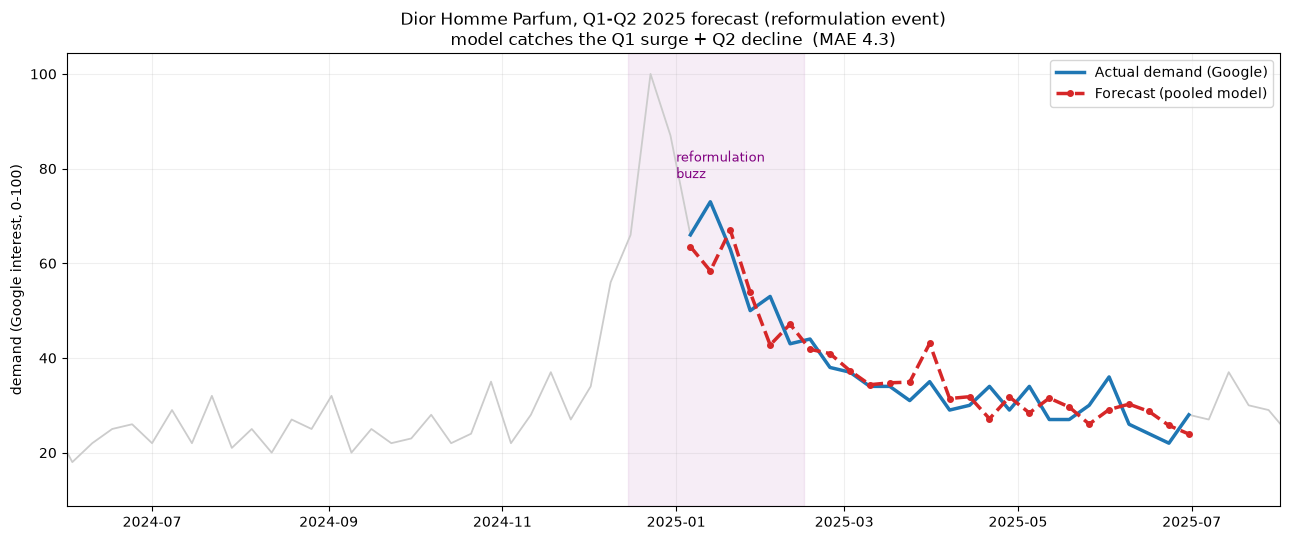

In [22]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# full demand history for context (faded)
fd = pooled_dhp[pooled_dhp.sku == "dior_homme_parfum"]
ax.plot(fd.week, fd.google_interest, color="#cccccc", lw=1.3)

# actual demand in the test window (bold)
ax.plot(test_d.week, test_d.google_interest, color="#1f77b4", lw=2.5,
        label="Actual demand (Google)")

# forecast (held-out window)
ax.plot(test_d.week, test_d.pred, color="#d62728", lw=2.5, ls="--",
        marker="o", ms=4, label="Forecast (pooled model)")

# mark the reformulation buzz window
ax.axvspan(pd.Timestamp("2024-12-15"), pd.Timestamp("2025-02-15"),
           color="purple", alpha=0.07)
ax.text(pd.Timestamp("2025-01-01"), 78, "reformulation\nbuzz", color="purple", fontsize=9)

ax.set_title("Dior Homme Parfum, Q1-Q2 2025 forecast (reformulation event)\n"
             "model catches the Q1 surge + Q2 decline  (MAE 4.3)", fontsize=12)
ax.set_ylabel("demand (Google interest, 0-100)")
ax.set_xlim(pd.Timestamp("2024-06-01"), pd.Timestamp("2025-08-01"))
ax.legend(loc="upper right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(ROOT / "data" / "charts" / "dhp_forecast.png", dpi=120)
plt.show()

In [24]:
plan_d, info_d = supply_plan(test_d, fd, "Dior Homme Parfum")
print(f"{info_d['label']:<20} base demand ~{info_d['base_demand']:.0f} u/wk | "
      f"safety stock {info_d['safety_stock']:.0f} | reorder point {info_d['reorder_point']:.0f}")

# the transient-surge insight: peak vs return-to-baseline
peak = test_d['google_interest'].max() * UNITS_PER_INTEREST
q2_avg = test_d[test_d.week >= '2025-04-01']['google_interest'].mean() * UNITS_PER_INTEREST
print(f"\nQ1 reformulation peak:  ~{peak:.0f} u/wk")
print(f"Q2 return-to-baseline:  ~{q2_avg:.0f} u/wk")
print(f"Insight: surge is TRANSIENT (+{(peak/q2_avg-1)*100:.0f}% in Q1, reverts by Q2) "
      f"-> size the bump, don't ramp standing inventory.")

Dior Homme Parfum    base demand ~544 u/wk | safety stock 920 | reorder point 3095

Q1 reformulation peak:  ~730 u/wk
Q2 return-to-baseline:  ~289 u/wk
Insight: surge is TRANSIENT (+152% in Q1, reverts by Q2) -> size the bump, don't ramp standing inventory.
